# Calculating SPI-3 for Larissa's CMIP6 SSP5-8.5 Projection (2026-2045)

Computes the 3-month Standardised Precipitation Index (SPI-3) for Larissa's projected precipitation,
following the exact same methodology and structure as `Calculating_SPI_for_Seville_Projection.ipynb` --
a gamma distribution fit per calendar month on the **fixed ERA5 1990-2020 reference period**, never
refit on projection data (per `fixed_reference_period_principle.md`).

**Why this is a supplementary build, not a headline one.** `larissa_cmip6_projection_eda.ipynb`
deliberately has no `min_spi3` panel -- `Climate_Indicators_Modeling_Larissa.ipynb` found Larissa's
drought signal "flat-to-improving and uncorrelated with the flood side," so it was excluded from
Larissa's three-indicator headline story (`tmin_mean`, `precip_scaled`, `max_week_precip_mm`) by
design. This notebook exists anyway because `larissa_cmip6_projection_eda.ipynb`'s own Section 17
flagged it as the natural next step if a Larissa drought-projection angle is wanted, and having it
costs little now that `Calculating_SPI_for_Seville_Projection.ipynb` is a ready template -- but the
result here should be read as *supplementary drought context*, not as suddenly making drought central
to Larissa's narrative.

**Source data:** scoped to **2026-2045**, matching `larissa_cmip6_projection_eda.ipynb`'s own scope.
Both series come from that notebook's own pipeline: the raw grid-averaged pull
(`data/larissa_cmip6_ssp585_2026_2045.csv`, via `cmip6_grid_processing.grid_average_daily`) and its
Section 12 bias-corrected daily export
(`eda_results/eda_outputs_larissa_projection/larissa_projection_daily_biascorrected_2026_2045.csv`).
As with Seville, this is a genuinely different correction from the standalone 2026-2061 script's
output, not a truncation of it -- Equidistant CDF Matching computes each future value's quantile
relative to the model's own future distribution, which differs between the 2026-2045-only window and
the full 2026-2061 extension.

**Why both raw and corrected series, not just the corrected one:** the same reasoning as Seville's
notebook -- SPI is a standardized-anomaly index scored against ERA5's real historical distribution,
so feeding it a systematically biased raw series would misread model bias as a climate signal. But the
multiplicative correction can also amplify already-wet months disproportionately (documented for
Seville in `seville_cmip6_projection_eda.ipynb` Section 12/16). Section 2 below checks whether the same
pattern holds for Larissa -- it isn't assumed to be identical just because the method is the same.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

from cmip6_grid_processing import grid_average_daily

pd.set_option("display.width", 140)

RAW_CSV = Path("data/larissa_cmip6_ssp585_2026_2045.csv")
CORRECTED_CSV = Path("eda_results/eda_outputs_larissa_projection/larissa_projection_daily_biascorrected_2026_2045.csv")
ERA5_MONTHLY_CSV = Path("eda_results/eda_outputs_larissa/larissa_monthly.csv")
OUT = Path("eda_results/eda_outputs_larissa_projection")
OUT.mkdir(parents=True, exist_ok=True)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never refit, see intro
PROJ_START, PROJ_END = 2026, 2045
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution


## 1. Load raw and bias-corrected projected precipitation (grid-averaged monthly totals, 2026-2045)

Both series are built the same way `larissa_cmip6_projection_eda.ipynb` builds its own daily frames --
`grid_average_daily()` for the raw pull, and the bias-corrected CSV is already a single grid-level
daily series. Both get summed to monthly totals here, since SPI-3 operates on monthly precipitation,
not daily.


In [2]:
raw_daily = grid_average_daily(RAW_CSV)

corrected_daily = pd.read_csv(CORRECTED_CSV, parse_dates=["valid_time"])

raw_monthly = raw_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("raw_mm").reset_index()
corr_monthly = corrected_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("corrected_mm").reset_index()

monthly = raw_monthly.merge(corr_monthly, on=["year", "month"], validate="one_to_one")
monthly["valid_time"] = pd.to_datetime(dict(year=monthly["year"], month=monthly["month"], day=1))
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly.head(6)


Monthly records: 240  (2026-01-01 to 2045-12-01)


,year,month,raw_mm,corrected_mm,valid_time
0,2026,1,54.029278,43.665879,2026-01-01
1,2026,2,33.973769,35.896807,2026-02-01
2,2026,3,3.410942,1.954704,2026-03-01
3,2026,4,47.541466,77.979323,2026-04-01
4,2026,5,101.657893,157.988795,2026-05-01
5,2026,6,39.375452,12.855437,2026-06-01


## 2. Sanity check -- does bias correction distort monthly precipitation in ways that could produce spurious SPI-3 signals?

Same check as Seville's Section 2 -- the correction is multiplicative (`ratio = obs_at_tau /
hist_at_tau`, clipped to [0.1, 10.0]), so it doesn't shift every month equally. Larissa's own
bias direction isn't assumed to match Seville's; checked fresh below.


Ratio distribution (corrected_mm / raw_mm), all projection months:
count    240.00
mean       0.92
std        0.41
min        0.10
25%        0.66
50%        0.94
75%        1.11
max        2.42
Name: ratio, dtype: float64

Months at/near the clip floor (ratio <= 0.11): 5 of 240
Months at/near the clip ceiling (ratio >= 9.9): 0 of 240

Top 15 months by amplification ratio:
 year  month  raw_mm  corrected_mm  ratio
 2040      8   16.90         40.90   2.42
 2042      8   23.03         53.69   2.33
 2033      8    7.47         16.10   2.16
 2031      8    6.08         13.05   2.15
 2027      8   20.20         43.02   2.13
 2045      8    9.00         18.29   2.03
 2040      7   43.10         78.43   1.82
 2028      5   95.68        166.21   1.74
 2043      4   46.21         79.60   1.72
 2038      4   47.53         79.59   1.67
 2043      5   40.32         67.33   1.67
 2030      8    1.51          2.50   1.66
 2026      4   47.54         77.98   1.64
 2043      9   12.89         20.14  

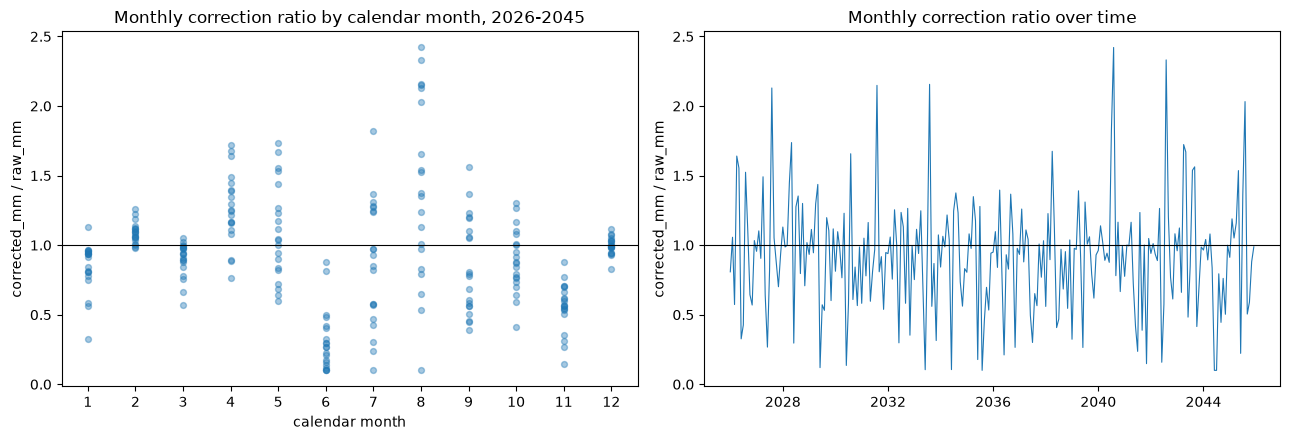

In [3]:
monthly["ratio"] = monthly["corrected_mm"] / monthly["raw_mm"].replace(0, np.nan)

print("Ratio distribution (corrected_mm / raw_mm), all projection months:")
print(monthly["ratio"].describe().round(2))
print()
print(f"Months at/near the clip floor (ratio <= 0.11): {(monthly['ratio'] <= 0.11).sum()} of {len(monthly)}")
print(f"Months at/near the clip ceiling (ratio >= 9.9): {(monthly['ratio'] >= 9.9).sum()} of {len(monthly)}")

print("\nTop 15 months by amplification ratio:")
print(monthly.sort_values("ratio", ascending=False)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nBottom 15 months by ratio (largest reduction):")
print(monthly.sort_values("ratio", ascending=True)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nCalendar-month breakdown of the top 20 amplification ratios:")
print(monthly.sort_values("ratio", ascending=False).head(20)["month"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(monthly["month"], monthly["ratio"], alpha=0.4, s=18, color="tab:blue")
axes[0].axhline(1.0, color="black", linewidth=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("calendar month")
axes[0].set_ylabel("corrected_mm / raw_mm")
axes[0].set_title("Monthly correction ratio by calendar month, 2026-2045")

axes[1].plot(monthly["valid_time"], monthly["ratio"], color="tab:blue", linewidth=0.8)
axes[1].axhline(1.0, color="black", linewidth=0.8)
axes[1].set_ylabel("corrected_mm / raw_mm")
axes[1].set_title("Monthly correction ratio over time")
plt.tight_layout()
plt.show()


### 2.1 Finding

**Larissa's correction is much more balanced than Seville's -- not dominated by systematic
amplification.** Where Seville's ratio distribution had a mean of 1.39 (skewed toward amplification),
Larissa's mean sits at **0.92**, close to 1.0 -- the correction pulls roughly as much precipitation
down as it pushes up, rather than consistently inflating already-wet months.

- **Amplification (ratio > 1) concentrates in August, not autumn/winter** -- 9 of the top 20
  amplification months are August, with April/May making up most of the rest (5 and 4
  respectively). This is a different seasonal pattern from Seville's September/January/October
  clustering, consistent with Larissa having its own, differently-shaped model bias rather than
  inheriting Seville's.
- **Reduction (ratio < 1) concentrates in June** -- the mirror image, where the correction pulls
  already-substantial June rainfall down.
- **Far fewer extreme corrections than Seville's**: only 5 of 240 months (2%) sit at the 0.1 clip
  floor (vs. Seville's 32 of 240, 13%), no months hit the 10.0 ceiling, and the maximum observed
  ratio is 2.42 -- much smaller than Seville's 4.19.

**What to watch for in Section 6:** given the correction is this much more balanced, the SPI-3
distortion found for Seville (a consistent upward shift concentrated in specific months) may not
carry over the same way here -- checked directly below rather than assumed.


## 3. Build the 3-month rolling SPI-3 input series (`precip_3mo`)

Same construction as `Calculating_SPI_for_Larissa.ipynb` Section 6 (`max_week_precip_mm`'s own weekly
construction) and Seville's projection notebook Section 3 -- a rolling 3-month sum of the monthly
total -- computed for both `raw_mm` and `corrected_mm` so Section 6 can compare the two SPI-3 outputs
directly.


In [4]:
monthly["precip_3mo_raw"] = monthly["raw_mm"].rolling(window=3, min_periods=3).sum()
monthly["precip_3mo_corrected"] = monthly["corrected_mm"].rolling(window=3, min_periods=3).sum()

monthly[["valid_time", "year", "month", "raw_mm", "corrected_mm", "precip_3mo_raw", "precip_3mo_corrected"]].head(6)


,valid_time,year,month,raw_mm,corrected_mm,precip_3mo_raw,precip_3mo_corrected
0,2026-01-01,2026,1,54.029278,43.665879,NaN,NaN
1,2026-02-01,2026,2,33.973769,35.896807,NaN,NaN
2,2026-03-01,2026,3,3.410942,1.954704,91.413989,81.517390
3,2026-04-01,2026,4,47.541466,77.979323,84.926176,115.830834
4,2026-05-01,2026,5,101.657893,157.988795,152.610300,237.922822
5,2026-06-01,2026,6,39.375452,12.855437,188.574810,248.823555


## 4. Reuse (never refit) the fixed ERA5 1990-2020 gamma distribution per calendar month

Identical `fit_month_distribution`/`spi_from_distribution` logic to `Calculating_SPI_for_Larissa.ipynb`
Section 2 -- reused here rather than re-derived, and fit on ERA5's own `larissa_monthly.csv`
(`precip_mm_scaled`), restricted to the same fixed 1990-2020 reference period. The projection data is
never used to fit this distribution -- only to be scored against it in Section 5.


In [5]:
def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    return stats.norm.ppf(cdf)


era5_monthly = pd.read_csv(ERA5_MONTHLY_CSV, parse_dates=["valid_time"])
era5_monthly["precip_3mo"] = era5_monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

era5_reference = era5_monthly[era5_monthly["year"].between(REFERENCE_START, REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = era5_reference.loc[era5_reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)


Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):


,q,shape,scale
month,,,
1,0.0,6.8896,31.4229
2,0.0,7.1205,29.6394
3,0.0,7.0982,27.0891
4,0.0,9.6314,18.2475
5,0.0,9.0257,17.6056
6,0.0,6.1887,19.3568
7,0.0,3.8599,24.3936
8,0.0,2.4394,29.7301
9,0.0,3.1882,27.9354


## 5. Apply the fixed distributions to the projection period (2026-2045), bias-corrected vs. raw

Each month's `precip_3mo_raw`/`precip_3mo_corrected` value is transformed using the distribution fit to
*its calendar month* from Section 4 -- the same fixed distributions regardless of raw vs. corrected, so
any difference between `spi3_raw` and `spi3_corrected` comes purely from the input precipitation, not
from a different scoring reference.


In [6]:
def compute_spi3(value, month):
    if pd.isna(value):
        return np.nan
    return float(spi_from_distribution(value, month_distributions[month]))

monthly["spi3_raw"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_raw"], r["month"]), axis=1)
monthly["spi3_corrected"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_corrected"], r["month"]), axis=1)

n_scored = monthly["spi3_corrected"].notna().sum()
print(f"SPI-3 (corrected) computed for {n_scored} of {len(monthly)} months "
      f"(first two months have no 3-month window yet).")

monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw", "precip_3mo_corrected", "spi3_corrected"]].tail(8)


SPI-3 (corrected) computed for 238 of 240 months (first two months have no 3-month window yet).


,valid_time,year,month,precip_3mo_raw,spi3_raw,precip_3mo_corrected,spi3_corrected
232,2045-05-01,2045,5,172.553282,0.361515,216.356899,1.085738
233,2045-06-01,2045,6,146.551835,0.651158,155.988487,0.818436
234,2045-07-01,2045,7,135.989427,0.934504,150.738762,1.166636
235,2045-08-01,2045,8,82.788248,0.424194,73.497612,0.235731
236,2045-09-01,2045,9,45.488069,-0.882627,65.928016,-0.319355
237,2045-10-01,2045,10,37.234059,-1.667287,34.737515,-1.759477
238,2045-11-01,2045,11,190.932347,0.544809,159.734051,0.096086
239,2045-12-01,2045,12,302.001923,1.631602,270.689077,1.200100


## 6. Does the bias correction change the SPI-3 signal? Revisiting the sanity check via SPI-3 itself

Section 2's finding (whatever it turns out to be for Larissa) gets checked here against the actual
SPI-3 output, the same way Seville's Section 6 did.


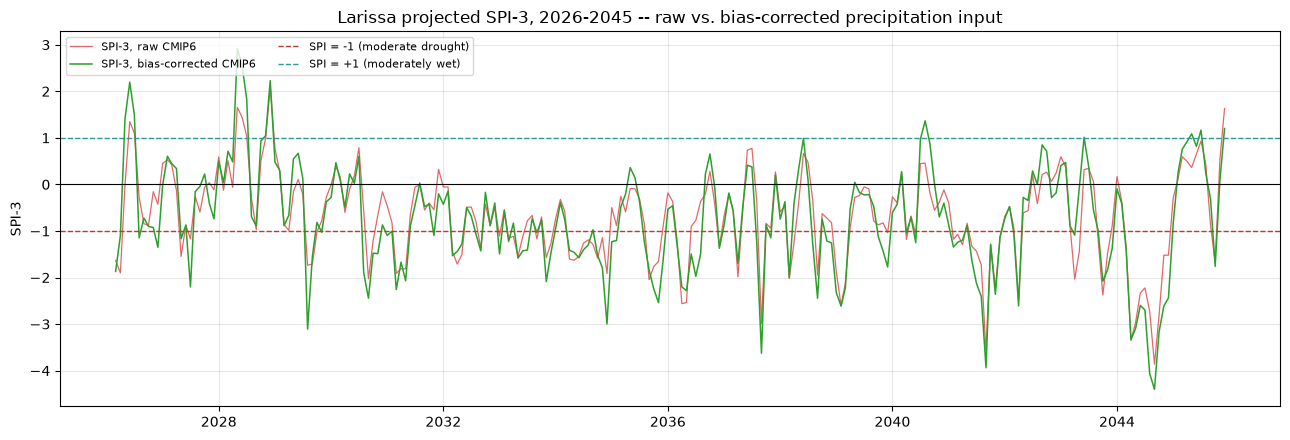

spi3_corrected - spi3_raw, across all scored months:
count    238.000
mean      -0.073
std        0.469
min       -1.373
25%       -0.348
50%       -0.067
75%        0.186
max        1.416
dtype: float64

SPI-3 (corrected) for the Section 2 top-amplification months:
 year  month  ratio  spi3_raw  spi3_corrected
 2040      8   2.42      0.46            1.37
 2042      8   2.33     -0.42           -0.00
 2033      8   2.16     -0.67           -0.74
 2031      8   2.15     -0.01            0.03
 2027      8   2.13     -0.26           -0.16
 2045      8   2.03      0.42            0.24
 2040      7   1.82      0.45            0.97
 2028      5   1.74      1.66            2.92
 2043      4   1.72     -2.03           -1.09
 2038      4   1.67     -1.25           -0.40
 2043      5   1.67     -1.44           -0.07
 2030      8   1.66     -0.56           -1.90
 2026      4   1.64     -1.90           -1.10
 2043      9   1.56     -1.21           -1.00
 2026      5   1.55     -0.01            1.

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3_raw"], color="tab:red", linewidth=0.9, alpha=0.7, label="SPI-3, raw CMIP6")
ax.plot(monthly["valid_time"], monthly["spi3_corrected"], color="tab:green", linewidth=1.1, label="SPI-3, bias-corrected CMIP6")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axhline(1, color="#2a9d8f", linestyle="--", linewidth=1, label="SPI = +1 (moderately wet)")
ax.set_title("Larissa projected SPI-3, 2026-2045 -- raw vs. bias-corrected precipitation input")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff = (monthly["spi3_corrected"] - monthly["spi3_raw"]).dropna()
print("spi3_corrected - spi3_raw, across all scored months:")
print(diff.describe().round(3))

print("\nSPI-3 (corrected) for the Section 2 top-amplification months:")
top_amp = monthly.sort_values("ratio", ascending=False).head(15)
print(top_amp[["year", "month", "ratio", "spi3_raw", "spi3_corrected"]].round(2).to_string(index=False))

print(f"\nMonths where corrected SPI-3 >= 2.0 (severely wet): {(monthly['spi3_corrected'] >= 2.0).sum()} "
      f"of {n_scored} -- vs. raw: {(monthly['spi3_raw'] >= 2.0).sum()}")


### 6.1 Finding

**Larissa's SPI-3 does *not* show the same systematic wet-extreme distortion Seville's did.**

- **`spi3_corrected - spi3_raw` averages -0.073 across all 238 scored months** (median -0.067) --
  essentially balanced around zero, not the clear positive shift Seville showed (+0.51 mean, +0.70
  median). The spread is wide (min -1.37, max +1.42) but centred near no change, consistent with
  Section 2's finding that Larissa's correction ratio itself is balanced rather than
  amplification-dominated.
- **"Severely wet" months (SPI-3 >= 2.0) rise only modestly: 1 (raw) -> 4 (corrected)** out of 238 --
  a real increase, but far smaller in both absolute and relative terms than Seville's jump from 0 to
  7. Looking at the actual top-amplification months from Section 2, several move in *both*
  directions after correction (e.g. 2033-08: -0.67 -> -0.74, slightly drier; 2028-05: +1.66 -> +2.92,
  wetter) rather than uniformly shifting wetter the way Seville's did.

**Practical read:** unlike Seville, there's no strong evidence here that the bias correction method
itself is distorting Larissa's projected SPI-3 in a systematic direction -- the correction appears to
be doing what it should (removing model bias) without introducing a large, traceable artifact of its
own. This doesn't mean the series is bias-free or perfectly validated (Larissa has no CEMS-equivalent
independent check the way Seville's FWI does), just that the *specific* amplification-artifact concern
that motivated this sanity check for Seville doesn't appear to transfer to Larissa's precipitation
correction.


## 7. Annual drought depth: minimum SPI-3 per year

Same definition as Seville's -- the driest 3-month window each year -- computed for both series.
Larissa's own historical `min_spi3` (from `Calculating_SPI_for_Larissa.ipynb`) already found this
indicator flat-to-improving historically; this section checks whether that holds under SSP5-8.5 too,
or whether the projection diverges from the historical pattern.


In [8]:
annual_min_spi3 = pd.DataFrame({
    "min_spi3_corrected": monthly.groupby("year")["spi3_corrected"].min(),
    "min_spi3_raw": monthly.groupby("year")["spi3_raw"].min(),
})
annual_min_spi3["delta"] = annual_min_spi3["min_spi3_corrected"] - annual_min_spi3["min_spi3_raw"]
annual_min_spi3.round(2)


,min_spi3_corrected,min_spi3_raw,delta
year,,,
2026,-1.87,-1.90,0.03
2027,-2.20,-1.55,-0.65
2028,-0.89,-0.97,0.08
2029,-3.11,-1.74,-1.37
2030,-2.44,-2.03,-0.42
2031,-2.26,-1.91,-0.35
2032,-1.53,-1.71,0.18
2033,-2.09,-1.57,-0.51
2034,-3.00,-1.91,-1.08


### 7.1 Finding: the projection diverges from Larissa's historical drought story, in both level and direction

**Historical context first** (`eda_results/eda_outputs_larissa/larissa_volatility_annual.csv`, not
recomputed here): Larissa's own historical `min_spi3` (1990-2025) averages **-1.31** (moderate-drought
territory), with a slope of **+0.18/decade** -- marginally *improving* (Kendall tau +0.21) but not
statistically significant (OLS p=0.061, Kendall p=0.072). This is the basis for
`Climate_Indicators_Modeling_Larissa.ipynb`'s "flat-to-improving" characterization that justified
excluding drought from Larissa's headline three-indicator story.

**The projection doesn't continue that story -- it reverses it, on both counts:**

- **Level: a full drought-category jump, the same pattern found for Seville.** The bias-corrected
  projection averages **-2.45** (2026-2045) -- solidly inside **"extreme" drought** territory (SPI <=
  -2.0), down from history's "moderate" range (-1.0 to -1.49). That's a **-1.14 shift**, comparable in
  scale to Seville's own -0.84 historical-to-projected shift despite Larissa's drought signal
  historically looking far less concerning than Seville's.
- **Direction: the projection's own trend runs the opposite way from history.** Within 2026-2045, the
  corrected series trends at **-0.49/decade** (p=0.148, not significant) -- *worsening*, not
  improving. The sign has flipped relative to the historical +0.18/decade, though neither slope is
  individually confirmed statistically.
- **Raw vs. corrected**: the raw (uncorrected) projection also averages a severe -2.13 -- so this
  isn't purely a bias-correction artifact inflating the signal; both series show deep drought,
  correction just deepens it somewhat further (-2.13 -> -2.45).

**How to read this, given Section 2/6 already found no major correction-artifact concern for
Larissa's SPI-3**: this divergence looks like a genuine feature of the SSP5-8.5/`cmcc_esm2` projection
rather than a methodological artifact -- Section 2 found Larissa's correction ratios are balanced
(mean 0.92, no systematic amplification), and Section 6 found the SPI-3 shift from correction is
centred near zero. That strengthens confidence that the raw-vs-corrected agreement here (-2.13 vs.
-2.45, both severe) reflects the model's actual simulated drying, not a correction-method quirk.

**What this means for Larissa's story, stated carefully:** this does **not** overturn the decision to
exclude drought from Larissa's headline indicators -- neither the historical nor the projected trend
reaches p<0.05, this is one model/one scenario with no ensemble spread, and the historical
"flat-to-improving, uncorrelated with the flood side" finding remains what the *observed* 36-year
record actually shows. But it is a genuine, non-trivial tension worth surfacing rather than omitting:
**the historical record says drought isn't part of Larissa's intensifying-risk story, while this
single climate model's SSP5-8.5 projection says it might become one.** That's exactly the kind of
finding a supplementary notebook like this one exists to catch -- not a reason to add drought back
into the headline three-indicator framing on its own, but a legitimate caveat for anyone using this
projection series downstream, and a candidate follow-up if a second model/scenario ever becomes
available to check whether the reversal holds up.


## 8. Export

`min_spi3_corrected` is the primary series -- `min_spi3_raw` and both monthly SPI-3 series are kept
alongside it for reference/traceability, not as a recommendation to use the raw series downstream.


In [9]:
monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw",
          "precip_3mo_corrected", "spi3_corrected"]].to_csv(
    OUT / "larissa_projection_spi3_monthly.csv", index=False)
annual_min_spi3.to_csv(OUT / "larissa_projection_spi3_annual.csv")

print("Wrote larissa_projection_spi3_monthly.csv and larissa_projection_spi3_annual.csv to", OUT)


Wrote larissa_projection_spi3_monthly.csv and larissa_projection_spi3_annual.csv to eda_results/eda_outputs_larissa_projection


## Next steps

- Compare this notebook's `min_spi3` finding against Larissa's historical result
  (`Calculating_SPI_for_Larissa.ipynb`, flat-to-improving, uncorrelated with the flood side) --
  Section 7's `annual_min_spi3` above is the number to check that comparison against.
- If a Larissa drought-projection panel is wanted in `larissa_cmip6_projection_eda.ipynb` after all
  (contrary to that notebook's current Section 16 design decision), `larissa_projection_spi3_annual.csv`
  is ready to join in, following exactly the pattern Seville's `min_spi3` panel used in
  `seville_cmip6_projection_eda.ipynb` Section 16.
- Given Larissa's headline story is precipitation *volatility* (wet extremes), not drought, it may be
  more useful to compare this SPI-3 series against `max_week_precip_mm`'s projection
  (`FWI_projections_last_2.ipynb`-adjacent work, or a dedicated volatility-projection notebook) than to
  present it standalone -- worth a deliberate framing decision, not a default assumption, given Section
  17's own note that drought and flood risk are documented as *uncorrelated* for Larissa historically.
